The bad result is:
{}


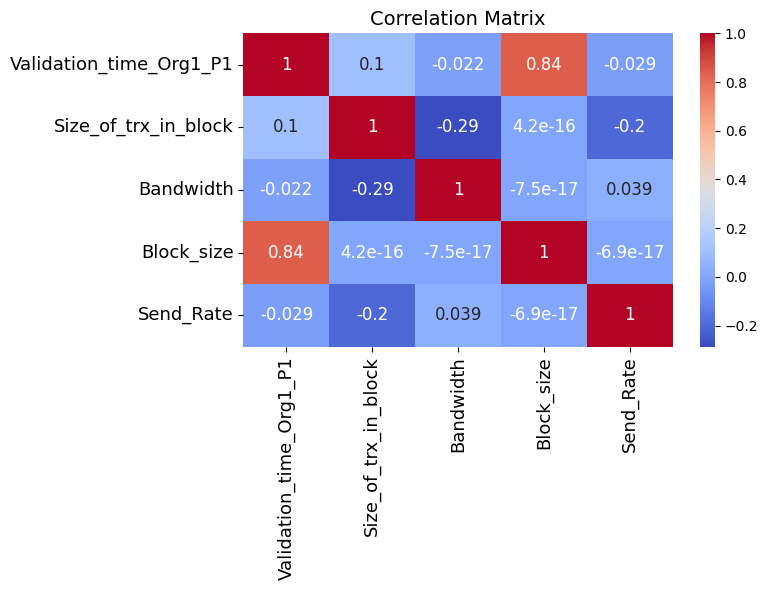

Correlation with 'Validation_time_Org1_P1':
Validation_time_Org1_P1    1.000000
Block_size                 0.840074
latancy                    0.765019
Size_of_trx_in_block       0.101438
Bandwidth                 -0.022143
Send_Rate                 -0.028524
throuout                  -0.788057
Name: Validation_time_Org1_P1, dtype: float64

Feature Importances:
                Feature  Importance
2            Block_size    0.973537
0  Size_of_trx_in_block    0.013472
3             Send_Rate    0.008403
1             Bandwidth    0.004588

Top 2 Features:
['Block_size', 'Size_of_trx_in_block']


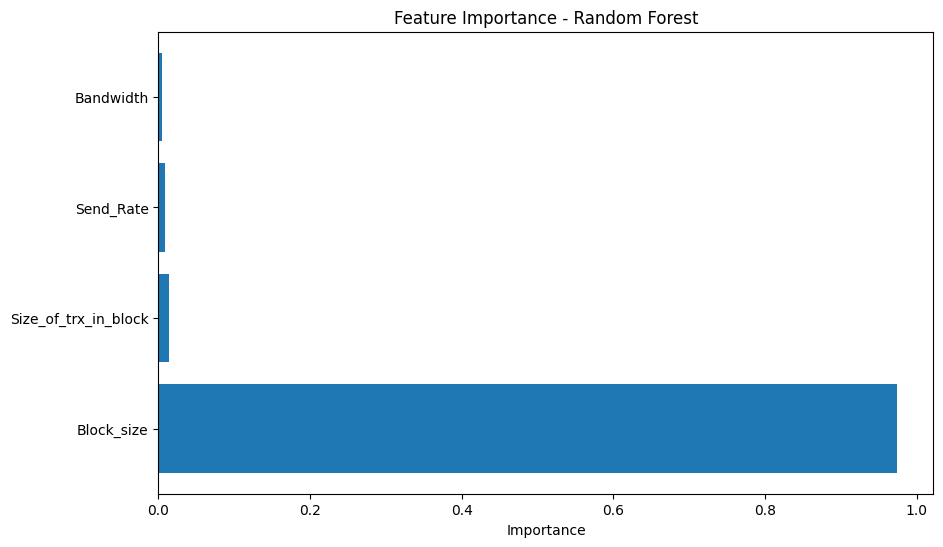

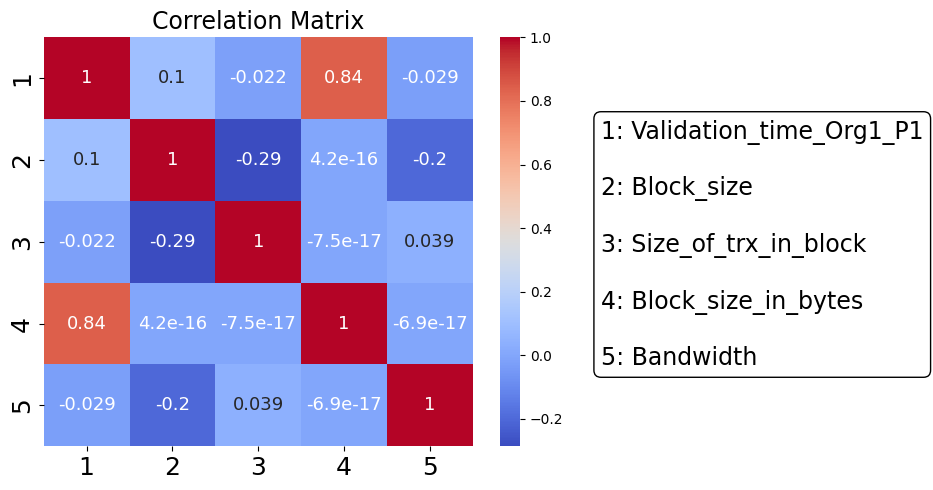

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ---- Your dataset ----
data = {


     "Size_of_trx_in_block": [2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                            2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                             
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              
                                8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                    
                             
                             
                             
                        ],
    "Bandwidth": [1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                   5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                   20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  
                          1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                    5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
 
                 ],
    "Block_size":[2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                 ],
    "Send_Rate":[10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
             
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                    10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
             
             
                ],


     
       "Validation_time_Org1_P1": [

0.001943897,
0.002619239,
0.003218896,
0.003709843,
0.004752123,
0.005442152,
0.006134292,
0.006842533,
0.007806551,
0.007042237,
0.007895986,
0.010063229,
0.011507413,
0.009904711,
0.011498091,
0.002499305,
0.003050014,
0.00388342,
0.004470509,
0.005654481,
0.006683268,
0.007432817,
0.007754238,
0.00866626,
0.008239395,
0.009108382,
0.010740676,
0.010451603,
0.010442521,
0.010489353,
0.001911498,
0.002512258,
0.003162925,
0.003984047,
0.004613701,
0.005714077,
0.006181703,
0.006720493,
0.008229605,
0.006832818,
0.008069051,
0.01149601,
0.009445899,
0.010100373,
0.010959411,
0.001904827,
0.002457584,
0.003407708,
0.004021678,
0.004876406,
0.005859027,
0.006416714,
0.00710506,
0.008189277,
0.007071107,
0.00862893,
0.010840848,
0.011230672,
0.009611543,
0.011064116,
0.001987429,
0.002518601,
0.003089535,
0.003831192,
0.004685103,
0.005362808,
0.00631024,
0.007342183,
0.007515984,
0.007146798,
0.007772621,
0.01064613,
0.009958218,
0.01090701,
0.011115807,
0.001936702,
0.002623667,
0.003204635,
0.003816711,
0.004595458,
0.005467941,
0.006670115,
0.006674049,
0.007996199,
0.0066781,
0.007735769,
0.010890804,
0.009633656,
0.010913949,
0.010386434,
0.001865956,
0.002509033,
0.003177152,
0.00376619,
0.004931539,
0.005300625,
0.006036589,
0.006542405,
0.00822041,
0.007407495,
0.007343618,
0.009358118,
0.011260769,
0.011110154,
0.011496271,
0.001969157,
0.002455555,
0.003224752,
0.003757227,
0.004812898,
0.005001955,
0.006609897,
0.007249128,
0.008230611,
0.00658094,
0.008339484,
0.010429247,
0.010804683,
0.01082951,
0.010391373,
0.001903503,
0.002537599,
0.003331958,
0.003906204,
0.004722301,
0.005279023,
0.006626016,
0.006378981,
0.007652297,
0.006396917,
0.007780504,
0.010899822,
0.010801872,
0.009364793,
0.011021499,
0.002018298,
0.00259592,
0.003171075,
0.003891414,
0.004815434,
0.005305842,
0.006026223,
0.006751674,
0.007783793,
0.006567895,
0.008237908,
0.010232064,
0.010621466,
0.010262149,
0.011127328,
0.002018298,
0.00259592,
0.003171075,
0.003891414,
0.004815434,
0.005305842,
0.006026223,
0.006751674,
0.007783793,
0.006567895,
0.008237908,
0.010232064,
0.010621466,
0.010262149,
0.011127328,
0.001873977,
0.002539675,
0.003021464,
0.004224023,
0.004835345,
0.005268806,
0.005743669,
0.007227833,
0.007693613,
0.006998403,
0.008000917,
0.009950152,
0.01054078,
0.010657452,
0.011123371,
0.001925839,
0.002522819,
0.003251986,
0.003810172,
0.00482396,
0.005632233,
0.005968354,
0.006968359,
0.00771331,
0.006590394,
0.00863535,
0.010217334,
0.010718147,
0.010671855,
0.010978954,
0.001922104,
0.00288163,
0.003084485,
0.003844185,
0.004931878,
0.0052958,
0.007041784,
0.007255835,
0.007821632,
0.007356106,
0.007835463,
0.011139749,
0.010107953,
0.011079856,
0.01104899,
0.001937586,
0.002470775,
0.003281099,
0.003881659,
0.004920325,
0.005315037,
0.006759528,
0.006886582,
0.007518359,
0.006536744,
0.007770213,
0.010581845,
0.011064476,
0.011044421,
0.010189898,
0.00190197,
0.002564506,
0.003138144,
0.004238808,
0.004691619,
0.00548786,
0.005994753,
0.007208332,
0.007517776,
0.006981652,
0.007793432,
0.010542482,
0.011287658,
0.010982577,
0.011018203,
0.001977947,
0.002658194,
0.00323712,
0.003785148,
0.004621217,
0.005719485,
0.007076464,
0.00698334,
0.007613706,
0.007052102,
0.008320088,
0.010704919,
0.012371434,
0.010416491,
0.010618583,
0.001899481,
0.002653782,
0.003472833,
0.003963285,
0.004843048,
0.005857793,
0.006265632,
0.006271278,
0.007495076,
0.006456653,
0.007729504,
0.010541503,
0.011076837,
0.011813424,
0.01162077,
0.002170799,
0.00279727,
0.003352842,
0.003862483,
0.004888088,
0.005579183,
0.006653918,
0.006884761,
0.007466253,
0.006858516,
0.008057288,
0.009541422,
0.010606876,
0.01204771,
0.011778366,
0.001924923,
0.002825471,
0.003270583,
0.004056242,
0.005126494,
0.005654583,
0.006390951,
0.00726945,
0.007588236,
0.007192176,
0.008161198,
0.010678159,
0.012703006,
0.010952004,
0.010814226,
0.001951093,
0.002615207,
0.003228702,
0.003867625,
0.005076777,
0.005405123,
0.005834108,
0.006712273,
0.006986457,
0.007033938,
0.007765345,
0.011086026,
0.009536296,
0.011921981,
0.010392411,
0.001945475,
0.002604352,
0.003387648,
0.004061164,
0.004513225,
0.005341856,
0.005921886,
0.006479007,
0.007729112,
0.007141527,
0.00743218,
0.011122555,
0.011168796,
0.011861585,
0.010989815,
0.001902804,
0.002701945,
0.003544587,
0.003846757,
0.004699872,
0.005494252,
0.006957035,
0.006742941,
0.007133055,
0.007089699,
0.008495248,
0.010789414,
0.011101359,
0.012229027,
0.011251071,
0.00194524,
0.002642277,
0.003191398,
0.003731195,
0.00490793,
0.005098063,
0.006288372,
0.007127486,
0.008120076,
0.006867977,
0.007957802,
0.010648863,
0.010707698,
0.01138444,
0.012366771,
0.002124249,
0.002712211,
0.00360342,
0.004218497,
0.005179687,
0.005553514,
0.006373768,
0.007270903,
0.007686952,
0.007539189,
0.008832744,
0.010651627,
0.011080363,
0.011758422,
0.01210645,
0.002063591,
0.002776812,
0.003622881,
0.004565752,
0.005267638,
0.005672417,
0.006305337,
0.007176375,
0.008637367,
0.007602856,
0.008791141,
0.011168942,
0.010996954,
0.011574271,
0.011454004,
0.002125513,
0.002869926,
0.003350182,
0.004198315,
0.004963548,
0.005939992,
0.006822339,
0.00699814,
0.007791973,
0.007373591,
0.008278053,
0.011190574,
0.01148953,
0.010742879,
0.012226831,
0.002067556,
0.002810144,
0.003308511,
0.004233128,
0.004993859,
0.006168667,
0.006828014,
0.007102013,
0.008459125,
0.007781849,
0.00776821,
0.011191711,
0.011868447,
0.012263834,
0.012666268,
0.00206287,
0.002799418,
0.003591232,
0.004173885,
0.005587585,
0.005661542,
0.006160175,
0.007195643,
0.007821807,
0.00725806,
0.008463853,
0.010584515,
0.011623605,
0.011384777,
0.012871395,
0.002032783,
0.002854397,
0.003393767,
0.004106858,
0.004834617,
0.005763025,
0.00621508,
0.006702354,
0.007426866,
0.008236014,
0.009340556,
0.011247646,
0.012355336,
0.011269622,
0.011499843,
0.002138351,
0.00272024,
0.003352814,
0.004019976,
0.005211235,
0.006187466,
0.006465308,
0.007141585,
0.008046336,
0.007628268,
0.009160339,
0.011449059,
0.009699892,
0.010817715,
0.010844936,
0.002074839,
0.002778281,
0.003520592,
0.004234133,
0.004949912,
0.006055217,
0.006722423,
0.007895756,
0.008643701,
0.007609201,
0.008862294,
0.010121785,
0.012161216,
0.011111573,
0.012269665,
0.002087316,
0.002808194,
0.003453919,
0.004137867,
0.004908409,
0.00606089,
0.006939765,
0.007682494,
0.008205129,
0.007630156,
0.009396412,
0.010930541,
0.011695852,
0.01129621,
0.011492601,
0.002004945,
0.002658039,
0.003438879,
0.004243049,
0.004869749,
0.005661614,
0.006215178,
0.006790583,
0.007420168,
0.007387508,
0.008872922,
0.010782004,
0.010161351,
0.011766735,
0.011610156,
0.002085114,
0.00275507,
0.003517477,
0.004014647,
0.004721323,
0.005802929,
0.006417635,
0.006531314,
0.007670124,
0.007506349,
0.007964505,
0.011535305,
0.011343665,
0.012035687,
0.011710749,
0.002194052,
0.002745552,
0.003379347,
0.004163435,
0.005286536,
0.005892426,
0.006478146,
0.006846191,
0.008162516,
0.007358024,
0.00897691,
0.010762665,
0.011262942,
0.01139042,
0.011872303,
0.001992913,
0.002685898,
0.003655897,
0.004342602,
0.005183121,
0.005639118,
0.006107278,
0.007638802,
0.008148886,
0.007596486,
0.008868555,
0.011056475,
0.011051812,
0.011568499,
0.011087322,
0.001957945,
0.002677147,
0.003398275,
0.004293994,
0.005224414,
0.006011221,
0.006559811,
0.006665021,
0.008596717,
0.006894056,
0.008285961,
0.01081702,
0.01207093,
0.012379984,
0.011372108,
0.002027642,
0.002636088,
0.003337341,
0.003801934,
0.005023468,
0.005639786,
0.006599487,
0.006790351,
0.007933321,
0.007494246,
0.008977565,
0.010547244,
0.012555571,
0.01177964,
0.011228999,
0.002355709,
0.002766702,
0.003590305,
0.005056231,
0.005893305,
0.005992845,
0.006878311,
0.007746935,
0.00785144,
0.008249909,
0.009622061,
0.012173987,
0.010889769,
0.011880764,
0.012345319,
0.002139865,
0.002786247,
0.003321339,
0.003836121,
0.005321455,
0.005598534,
0.006338161,
0.007331663,
0.007878228,
0.007202272,
0.008273274,
0.00997558,
0.011176106,
0.010747095,
0.011607017,
0.002095739,
0.002628127,
0.003600853,
0.003910447,
0.00538815,
0.005633941,
0.006528455,
0.007492612,
0.007985934,
0.006979917,
0.008148881,
0.010599104,
0.011715507,
0.011153293,
0.01094546,
0.002665252,
0.003408011,
0.004042868,
0.004611372,
0.005437548,
0.006577813,
0.008118888,
0.007321367,
0.008503371,
0.007983332,
0.010174969,
0.012207819,
0.011468288,
0.011575527,
0.011509555,
0.002313915,
0.003092215,
0.003645358,
0.004307903,
0.005663686,
0.006985055,
0.007827919,
0.008064208,
0.009388156,
0.008124271,
0.009279244,
0.012219668,
0.012469386,
0.012301644,
0.012178345,
0.002334429,
0.003067852,
0.003690936,
0.004431042,
0.005674672,
0.006554177,
0.00706423,
0.007594155,
0.008664632,
0.008370774,
0.009492344,
0.012228856,
0.010741791,
0.011146536,
0.011278636,
0.002401952,
0.002887635,
0.003858019,
0.004600387,
0.005667518,
0.006515874,
0.007150194,
0.008080731,
0.008949802,
0.008465537,
0.01033439,
0.011767357,
0.011711099,
0.011587276,
0.011531243,
0.002609462,
0.003111123,
0.003996268,
0.00459917,
0.005577142,
0.006352762,
0.006695382,
0.007936777,
0.008672253,
0.008150586,
0.009287595,
0.011299413,
0.011188953,
0.010662741,
0.011685864,
0.002437458,
0.003018247,
0.003805938,
0.004873234,
0.005552868,
0.006477894,
0.007196138,
0.008133826,
0.007925486,
0.008021575,
0.010629265,
0.011633289,
0.010776283,
0.011334464,
0.011455684,
0.002601995,
0.00381208,
0.004119527,
0.004444321,
0.005523995,
0.006891446,
0.006884861,
0.008254482,
0.008961707,
0.008117874,
0.009715269,
0.011545649,
0.010533546,
0.010722241,
0.011597221,
0.002251241,
0.003192112,
0.00402639,
0.005081683,
0.005552291,
0.006572709,
0.006815534,
0.008084445,
0.007923676,
0.008072815,
0.009658712,
0.011336578,
0.010982122,
0.011248275,
0.012364132,
0.00243177,
0.003064929,
0.00415966,
0.00454317,
0.00540458,
0.006143946,
0.007087759,
0.007422343,
0.008023208,
0.008117597,
0.009679523,
0.012401614,
0.012288509,
0.010349476,
0.010545776,
0.002515375,
0.003184811,
0.003831906,
0.004807116,
0.005857617,
0.006322188,
0.007241786,
0.007889734,
0.008169601,
0.008328728,
0.009215665,
0.011635396,
0.011316934,
0.012248036,
0.011611029,
0.002412318,
0.003086589,
0.003731284,
0.004239848,
0.005341442,
0.007058058,
0.006663705,
0.007568105,
0.007850633,
0.008139951,
0.010067175,
0.011535325,
0.010699677,
0.011234809,
0.011032047,
0.002408348,
0.00318529,
0.004001598,
0.004948005,
0.005207169,
0.006200594,
0.006985797,
0.007918265,
0.008012318,
0.00807242,
0.010241814,
0.012843455,
0.011730932,
0.011534291,
0.011818492,
                                   
                               ],
    
    
    
    
    
        "throuout":[35,
35,
32.4,
28.9,
34.8,
56.9,
23.4,
24.4,
21.7,
14.8,
5,
2.2,
0.7,
0.6,
0.6,
33.1,
33.3,
31.7,
28.5,
32.1,
68.5,
24.4,
24.9,
24.9,
12.5,
4.2,
2.1,
0.7,
0.6,
0.7,
35,
35.4,
31.5,
29.4,
33.3,
57,
25.1,
22.2,
19.5,
10.6,
5.2,
2.1,
0.7,
0.7,
0.7,
35.1,
35.2,
31.1,
27.8,
33.3,
53.4,
25,
22.3,
21.6,
19.7,
6,
2.2,
0.7,
0.7,
0.6,
34.9,
35.1,
32.5,
26.7,
34.4,
52.3,
28.1,
23.2,
23.8,
16.2,
5.1,
1.5,
0.6,
0.7,
0.6,
35.1,
35.2,
31.6,
28.5,
34.7,
46.3,
25.7,
26.5,
25.4,
16,
3.7,
2.1,
0.7,
0.6,
0.6,
35.2,
35,
31.8,
25.7,
33.6,
67.6,
24.3,
24.3,
24,
16.5,
5.3,
2.2,
0.7,
0.6,
0.7,
35.2,
35.4,
31.6,
27.6,
34.5,
70.5,
26.2,
24.2,
21.4,
13.5,
5.6,
2.2,
0.6,
0.6,
0.7,
                    
                    34.6,
35.2,
31.7,
29.3,
33.8,
76.9,
24.7,
26.9,
24,
15.5,
3,
2.2,
0.6,
0.7,
0.6,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35,
35.1,
32.3,
27.4,
34.5,
64.9,
11.9,
25.9,
20.4,
12.8,
3.7,
2.2,
0.7,
0.7,
0.7,
34.9,
35,
31.9,
26.7,
33.1,
65,
26.4,
24.1,
17.7,
14.7,
2.8,
1.5,
0.7,
0.7,
0.7,
35.1,
34.8,
32.1,
27.3,
34.5,
55.2,
26,
26.2,
23,
17.8,
5.7,
2.2,
0.7,
0.7,
0.6,
35,
35.2,
32.8,
29.8,
34.5,
51.9,
24.7,
27.1,
23.8,
16.6,
3.7,
1.5,
0.7,
0.6,
0.7,
35,
34.9,
33,
27.7,
34.8,
63.4,
27,
25.7,
21.2,
18.6,
5.3,
2.2,
0.7,
0.7,
0.7,
                    35.4,
35.3,
31.8,
29.2,
34.6,
51.9,
26.5,
25.9,
22.7,
15.5,
3.3,
2.2,
0.7,
0.6,
0.6,
34.9,
35.1,
32.6,
27,
33.4,
59.7,
26.5,
18.7,
22.6,
12.5,
3,
1.5,
0.6,
0.7,
0.7,
33.9,
34.5,
32,
27.8,
33.4,
43.6,
23.4,
27.4,
13.2,
16.8,
4.1,
1.4,
0.7,
0.7,
0.6,
34.7,
34.7,
32.4,
29.7,
34.2,
74.8,
25.8,
24.5,
19.4,
19.3,
4.8,
2.2,
0.7,
0.7,
0.6,
34.9,
35.2,
31.5,
29.8,
34.6,
59.9,
29.5,
22.6,
22,
19.2,
4.2,
1.4,
0.7,
0.6,
0.6,
34.5,
35.1,
32.5,
30,
33.6,
64.7,
27.1,
20.6,
25.4,
18.5,
5.2,
2.2,
0.7,
0.7,
0.7,
34.6,
35.2,
32.3,
28.4,
34.7,
64.3,
25.4,
19.5,
24.1,
14.7,
6.7,
2.1,
0.7,
0.7,
0.7,
35,
35.2,
32.1,
29.4,
34.3,
63.1,
23.7,
17.1,
21.6,
15.3,
3.5,
2.1,
0.7,
0.7,
0.6,
                    34.6,
34.8,
32.3,
29,
34.3,
61.7,
27.9,
26.5,
24.6,
18.3,
3.7,
2.1,
0.6,
0.6,
0.7,
34.6,
34.8,
31.5,
29.7,
33.7,
28,
27,
23.3,
21.7,
17.8,
5.2,
2.1,
0.7,
0.6,
0.7,
34.2,
34.7,
31.6,
28.3,
33.3,
53.8,
26.5,
24.9,
25.5,
16.5,
3.1,
2.2,
0.6,
0.7,
0.7,
34.8,
34.9,
31.5,
29.2,
34.5,
64.4,
23.5,
23.1,
21.9,
14.1,
3.4,
2.2,
0.6,
0.7,
0.6,
34.7,
34.8,
30.7,
29.9,
33.1,
64.5,
24.3,
25.2,
25.4,
14.1,
7.4,
2.2,
0.7,
0.6,
0.6,
34.8,
34.8,
31.1,
28,
31.7,
88,
27,
21.5,
24.6,
17.3,
4.5,
1.5,
0.7,
0.7,
0.7,
                    34.6,
34.2,
32.2,
28.2,
33.2,
60.6,
24.3,
23.9,
24.8,
15.8,
6.2,
2.1,
0.6,
0.7,
0.7,
34.9,
35,
32.3,
28.8,
33.8,
60.2,
26.2,
25.6,
26,
16.3,
5.2,
2.2,
0.7,
0.6,
0.6,
34.5,
34.4,
31.2,
30.9,
33.8,
42.8,
26.5,
24.1,
25.4,
15,
4.6,
2.2,
0.7,
0.7,
0.7,
34.7,
34.6,
31.3,
28.5,
33.9,
61.7,
25.1,
25.9,
25.6,
15.2,
6,
2.1,
0.6,
0.7,
0.6,
34.6,
34.7,
31.6,
29.5,
31.9,
50.8,
28,
26.4,
25.3,
15.3,
4.3,
1.4,
0.6,
0.7,
0.7,
34.2,
34.7,
31.8,
30,
32.7,
53.4,
25.6,
26.3,
23.4,
16.3,
6.7,
2.1,
0.7,
0.7,
0.7,
                    34.7,
34.5,
31.4,
28.4,
33.7,
63.3,
24.3,
24,
20,
14.6,
7.5,
2.2,
0.7,
0.7,
0.7,
34.5,
34.6,
32.1,
28.3,
32.6,
66.5,
26.6,
25.6,
19.3,
13.9,
3.7,
2.1,
0.7,
0.6,
0.6,
34.4,
34.4,
32.1,
28.4,
34.1,
59.8,
26.6,
25.7,
22.2,
18.1,
4.2,
1.6,
0.7,
0.7,
0.6,
34,
34.4,
31.7,
25.4,
30.9,
32.7,
25.3,
24.3,
26.6,
11.8,
5.4,
2.1,
0.7,
0.7,
0.7,
34.5,
34.8,
32.3,
28,
34.1,
56.8,
25.4,
21,
20.4,
18.8,
4.2,
2.2,
0.7,
0.6,
0.7,
34.4,
34.8,
31.7,
27.7,
33.1,
65,
27,
20.8,
25.9,
17,
3.3,
1.4,
0.7,
0.7,
0.7,
                    33.7,
32.5,
31.2,
27.2,
33.8,
66.5,
23.8,
25.7,
24.5,
12.7,
5.6,
2.1,
0.7,
0.6,
0.7,
34.4,
34.6,
31.6,
28.1,
31.9,
60.9,
25.5,
23.9,
23,
11.2,
4,
2.1,
0.6,
0.6,
0.7,
34.1,
33.9,
31.6,
27.8,
33.3,
55.6,
26.5,
24.4,
19.6,
12.5,
4.2,
2.1,
0.7,
0.7,
0.6,
34.1,
34,
31.9,
28.1,
32.5,
55.8,
20.5,
23.9,
22.1,
14.4,
8,
2.1,
0.7,
0.7,
0.7,
34.1,
34.3,
30.8,
28.4,
32.9,
13.3,
23.5,
25.6,
21.1,
12.5,
2.9,
1.5,
0.7,
0.7,
0.6,
34,
33.7,
31.8,
28.3,
31.7,
63.5,
26.5,
25.1,
21.5,
12.1,
4.4,
1.4,
0.6,
0.7,
0.7,
                    33.3,
30.5,
30.3,
27.1,
30.9,
53.2,
23.9,
23.4,
24.9,
15.3,
4.1,
2.1,
0.6,
0.7,
0.6,
33.6,
34.4,
31.4,
27.3,
33.4,
64.1,
25.3,
24.3,
20.7,
15.2,
3.6,
2.1,
0.7,
0.7,
0.7,
34.3,
34.1,
30.9,
28.7,
33.5,
53.2,
25.5,
25,
21.4,
12.5,
5.7,
2.1,
0.7,
0.7,
0.7,
34.1,
34,
30.9,
29,
33.7,
64.4,
20.1,
23.7,
23.7,
18.4,
3.6,
2.1,
0.7,
0.6,
0.6,
34,
33.9,
30.7,
29.1,
33,
38.5,
26.6,
26.1,
21.9,
17.1,
4.2,
1.4,
0.7,
0.7,
0.7,
33.8,
33.9,
31.8,
27.1,
32,
42.7,
27.4,
25.9,
23.9,
16.4,
6,
2.2,
0.7,
0.7,
0.7,
               
               ],
    "latancy":[0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.17,
0.19,
0.42,
1.28,
3.88,
12.51,
13.48,
13.49,
0.11,
0.12,
0.1,
0.11,
0.19,
0.1,
0.15,
0.17,
0.16,
0.52,
1.36,
4.09,
12.54,
13.45,
12.64,
0.09,
0.11,
0.09,
0.1,
0.18,
0.1,
0.14,
0.19,
0.22,
0.57,
1.19,
4.08,
12.48,
12.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.19,
0.19,
0.3,
1.17,
3.9,
12.53,
12.7,
13.67,
0.09,
0.11,
0.09,
0.11,
0.17,
0.11,
0.12,
0.19,
0.17,
0.37,
1.2,
6.27,
13.12,
12.64,
13.35,
0.09,
0.11,
0.09,
0.1,
0.17,
0.12,
0.14,
0.16,
0.16,
0.39,
1.38,
4.01,
12.39,
13.65,
13.21,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.14,
0.17,
0.17,
0.36,
1.15,
3.94,
12.47,
13.75,
12.56,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.13,
0.18,
0.2,
0.45,
1.11,
3.85,
13.04,
13.74,
12.91,
               
               
               0.09,
0.11,
0.09,
0.1,
0.17,
0.08,
0.14,
0.15,
0.17,
0.38,
1.68,
3.8,
13.24,
12.68,
13.66,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.11,
0.18,
0.09,
0.31,
0.15,
0.2,
0.48,
1.37,
4.02,
12.48,
12.64,
12.91,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.17,
0.25,
0.42,
1.57,
7.01,
12.4,
12.62,
12.79,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.16,
0.18,
0.34,
1.26,
3.88,
12.35,
12.66,
13.1,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.36,
1.43,
6.35,
12.47,
13.11,
12.87,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.17,
0.19,
0.32,
1.14,
3.88,
12.52,
12.67,
12.89,
               0.09,
0.11,
0.09,
0.1,
0.17,
0.11,
0.13,
0.16,
0.18,
0.39,
1.56,
3.96,
12.6,
13.7,
13.21,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.23,
0.18,
0.49,
1.67,
6.93,
13.05,
12.65,
12.55,
0.1,
0.11,
0.09,
0.11,
0.18,
0.12,
0.15,
0.15,
0.35,
0.35,
1.39,
6.8,
12.49,
12.63,
13.43,
0.09,
0.12,
0.09,
0.1,
0.18,
0.08,
0.13,
0.17,
0.22,
0.31,
1.3,
4.12,
12.55,
12.59,
13.32,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.11,
0.18,
0.18,
0.31,
1.39,
7.05,
12.47,
13.69,
13.2,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.12,
0.21,
0.15,
0.33,
1.14,
3.77,
12.42,
12.67,
12.56,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.14,
0.21,
0.16,
0.42,
0.99,
4.2,
12.53,
12.65,
12.91,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.26,
0.19,
0.39,
1.45,
4.04,
12.48,
12.68,
13.37,
               0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.12,
0.16,
0.16,
0.33,
1.4,
4.16,
13.34,
13.42,
12.88,
0.09,
0.11,
0.1,
0.1,
0.18,
0.17,
0.12,
0.18,
0.19,
0.34,
1.19,
4.11,
12.48,
13.03,
12.49,
0.1,
0.11,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.15,
0.37,
1.65,
3.95,
13.11,
12.63,
12.91,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.15,
0.18,
0.19,
0.44,
1.51,
3.88,
12.79,
12.69,
13.34,
0.1,
0.11,
0.1,
0.1,
0.18,
0.1,
0.14,
0.16,
0.16,
0.44,
1.04,
4.03,
12.47,
13.73,
13.58,
0.1,
0.11,
0.1,
0.11,
0.18,
0.08,
0.12,
0.2,
0.16,
0.34,
1.37,
7.11,
12.49,
12.65,
12.54, 0.1,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.18,
0.16,
0.38,
1.18,
4.35,
12.88,
12.65,
12.39,
0.09,
0.11,
0.1,
0.1,
0.17,
0.1,
0.13,
0.17,
0.16,
0.37,
1.17,
3.95,
12.47,
13.7,
13.24,
0.1,
0.12,
0.1,
0.1,
0.18,
0.13,
0.13,
0.18,
0.16,
0.42,
1.3,
3.93,
12.44,
12.65,
12.83,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.16,
0.15,
0.4,
1.19,
4.13,
12.79,
12.67,
13.19,
0.09,
0.11,
0.1,
0.1,
0.18,
0.11,
0.12,
0.15,
0.15,
0.4,
1.32,
7.48,
13,
12.64,
12.9,
0.1,
0.12,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.38,
1.17,
4.13,
12.5,
12.65,
12.87,
               0.09,
0.11,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.21,
0.42,
1.06,
3.95,
12.43,
12.67,
12.56,
0.09,
0.11,
0.1,
0.11,
0.18,
0.09,
0.13,
0.16,
0.22,
0.44,
1.41,
4.09,
12.49,
13.28,
13.34,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.13,
0.16,
0.18,
0.33,
1.4,
5.6,
12.48,
12.68,
13.45,
0.1,
0.12,
0.1,
0.13,
0.19,
0.15,
0.14,
0.17,
0.14,
0.55,
1.21,
4.28,
12.38,
12.65,
12.89,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.2,
0.2,
0.32,
1.37,
3.94,
12.43,
13.61,
12.91,
0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.13,
0.21,
0.15,
0.36,
1.57,
7.09,
12.48,
12.63,
12.86,
               
               0.1,
0.13,
0.11,
0.11,
0.18,
0.1,
0.15,
0.16,
0.16,
0.49,
1.24,
4.24,
12.39,
13.61,
12.93,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.19,
0.57,
1.41,
4.21,
12.99,
13.74,
12.87,
0.1,
0.12,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.22,
0.5,
1.35,
4.48,
12.52,
12.6,
13.31,
0.1,
0.12,
0.1,
0.11,
0.19,
0.11,
0.18,
0.18,
0.19,
0.41,
0.94,
4.17,
12.45,
12.63,
12.85,
0.1,
0.12,
0.1,
0.11,
0.18,
0.31,
0.15,
0.17,
0.2,
0.5,
1.6,
7.35,
12.22,
12.63,
13.2,
0.1,
0.12,
0.1,
0.11,
0.19,
0.1,
0.14,
0.17,
0.19,
0.52,
1.39,
6.85,
12.3,
12.7,
12.88,
               
               0.11,
0.15,
0.11,
0.12,
0.19,
0.11,
0.15,
0.19,
0.16,
0.4,
1.42,
4.14,
12.87,
12.64,
13.11,
0.1,
0.12,
0.1,
0.12,
0.18,
0.1,
0.14,
0.17,
0.21,
0.41,
1.44,
4.28,
12.46,
12.57,
12.67,
0.1,
0.12,
0.1,
0.11,
0.18,
0.11,
0.14,
0.17,
0.2,
0.5,
1.22,
4.13,
12.47,
12.57,
12.89,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.18,
0.18,
0.17,
0.32,
1.56,
4.18,
12.52,
13.72,
13.35,
0.1,
0.12,
0.1,
0.11,
0.18,
0.14,
0.13,
0.16,
0.19,
0.36,
1.33,
7.12,
12.42,
12.59,
12.55,
0.1,
0.12,
0.1,
0.12,
0.19,
0.13,
0.13,
0.16,
0.18,
0.38,
1.19,
4.05,
12.34,
12.6,
12.91,
              ],
}
df = pd.DataFrame(data)



lengths = {k: len(v) for k, v in data.items()}
lengths_sorted = dict(sorted(lengths.items(), key=lambda x: x[1]))
lengths_sorted
n = max(lengths.values())
bad = {k: (len(v), n) for k,v in data.items() if len(v) != n}
print("The bad result is:")
print(bad)


# Create new feature 'Size_of_block'


# Calculate correlation matrix
 
correlation_matrix = df[['Validation_time_Org1_P1', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})  

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=14)  # Make the title bigger
plt.xticks(fontsize=13)  # X-axis labels
plt.yticks(fontsize=13)  # Y-axis labels

# Save the heatmap as a high-quality PDF
plt.tight_layout() 
plt.savefig('validation_correlation_matrix.pdf', format='pdf', dpi=600)  # Save as PDF with 300 DPI

# Show the plot
plt.show()

# Optionally print the correlation values
correlation_matrix = df.corr()
print("Correlation with 'Validation_time_Org1_P1':")
print(correlation_matrix['Validation_time_Org1_P1'].sort_values(ascending=False))

# Train a Random Forest model to find feature importances
X = df[[ 'Size_of_trx_in_block', 'Bandwidth','Block_size','Send_Rate']]
y = df['Validation_time_Org1_P1']

# Fit Random Forest model
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X, y)

# Feature importances
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Print feature importances
print("\nFeature Importances:")
print(importance_df)

# Choose the two most important features based on correlation and importance
top_features = importance_df.sort_values(by='Importance', ascending=False).head(2)['Feature'].tolist()
print("\nTop 2 Features:")
print(top_features)

# Prepare polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[top_features])

# Visualizing feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.show()





np.random.seed(42)
df = pd.DataFrame(data)

# Creating 'Size_of_block'
df['Block_size_in_bytes'] = df['Block_size'] * df['Size_of_trx_in_block']

# Calculate correlation matrix
correlation_matrix = df[['Validation_time_Org1_P1', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
# Assigning numbers to variable names for a shorter legend
variable_mapping = {
    1: 'Validation_time_Org1_P1',
    2: 'Block_size',
    3: 'Size_of_trx_in_block',
    4: 'Block_size_in_bytes',
    5: 'Bandwidth'
}

# Replace variable names with their corresponding numbers
correlation_matrix.index = [str(i) for i in variable_mapping.keys()]
correlation_matrix.columns = [str(i) for i in variable_mapping.keys()]

plt.figure(figsize=(6,5))  # Increase figure size to accommodate the legend box
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 13})

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=17)  # Make the title bigger
plt.xticks(fontsize=18)  # X-axis labels
plt.yticks(fontsize=18)  # Y-axis labels

# Add a legend box to indicate variable numbers, positioned inside the plot with a border
legend_labels = [f"{num}: {name}" for num, name in variable_mapping.items()]
legend_text = "\n\n".join(legend_labels) 

# Position the legend box within the figure bounds to ensure it is saved correctly
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
plt.gcf().text(1.01, 0.5, legend_text, fontsize=17, verticalalignment='center', bbox=props)

# Save the heatmap as a high-quality PDF with all content visible
plt.tight_layout()
plt.savefig('validation_correlation_matrix_with_legend.pdf', format='pdf', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


Baseline (mean): {'MAE': 0.002507207499256973, 'RMSE': 0.003017061040600995, 'MSE': 9.102657322712359e-06, 'R2': -0.0061463447106970825, 'MAPE(%)': 53.773077996782746}
Baseline (Block_size only): {'MAE': 0.0013662466339120246, 'RMSE': 0.0016745520908436008, 'MSE': 2.804124704948675e-06, 'R2': 0.6900509684180467, 'MAPE(%)': 27.55682671122517}

=== Test-set results (single split) ===

Linear Regression:
  MAE:     0.0013168312
  RMSE:    0.0015996086
  MSE:     2.5587475965e-06
  R2:      0.717173
  MAPE(%): 26.4265

Decision Tree:
  MAE:     0.0004183327
  RMSE:    0.0005705182
  MSE:     3.2549100726e-07
  R2:      0.964022
  MAPE(%): 6.1328

Random Forest:
  MAE:     0.0003195362
  RMSE:    0.0004297242
  MSE:     1.8466287497e-07
  R2:      0.979589
  MAPE(%): 4.6486

XGBoost:
  MAE:     0.0003158064
  RMSE:    0.0004211004
  MSE:     1.7732555281e-07
  R2:      0.980400
  MAPE(%): 4.8671

Polynomial (Quadratic) equation (on standardized features):
Validation_time = (-0.00159597 * x1

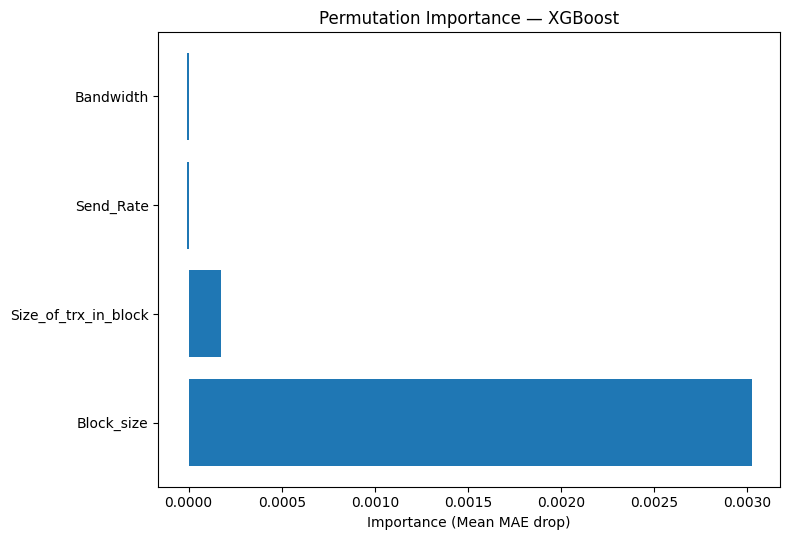

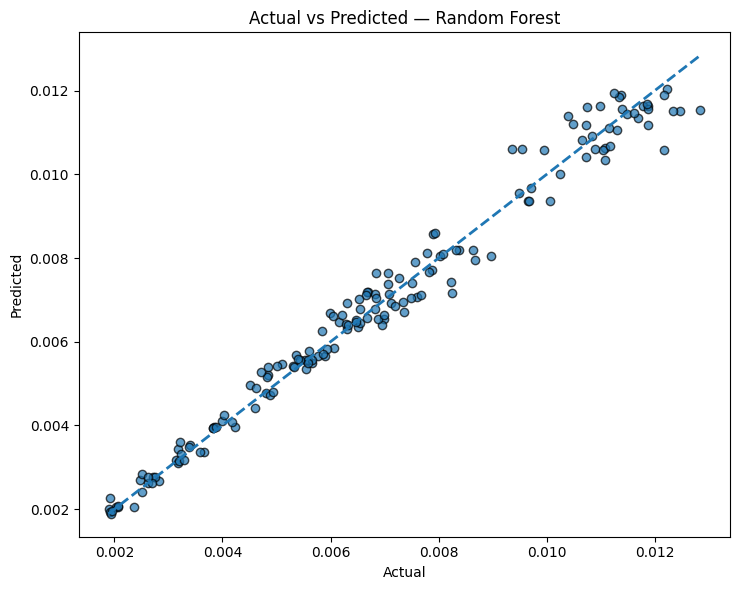

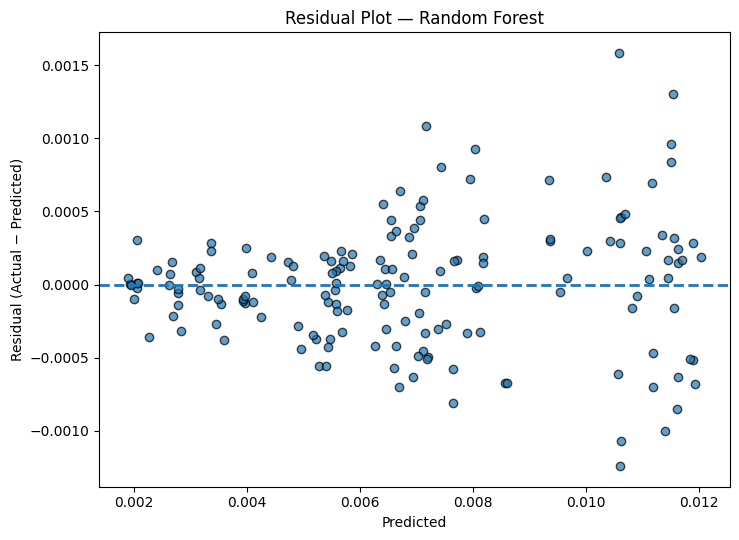

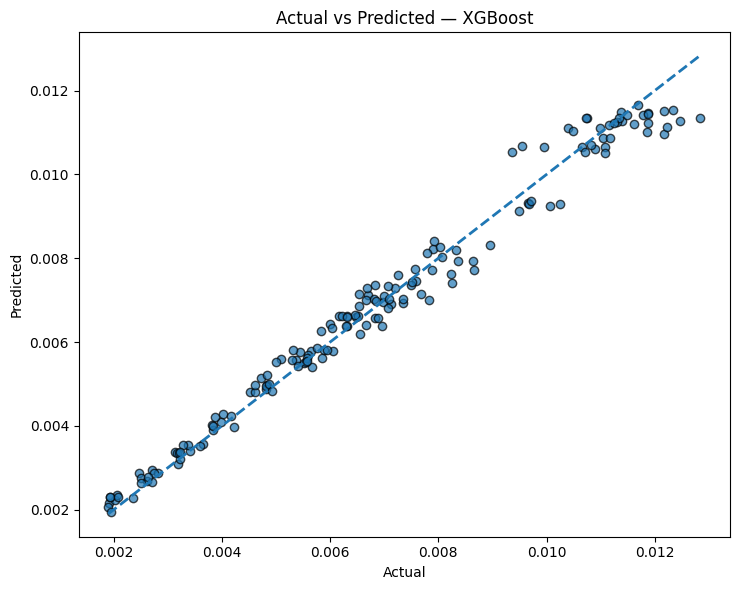

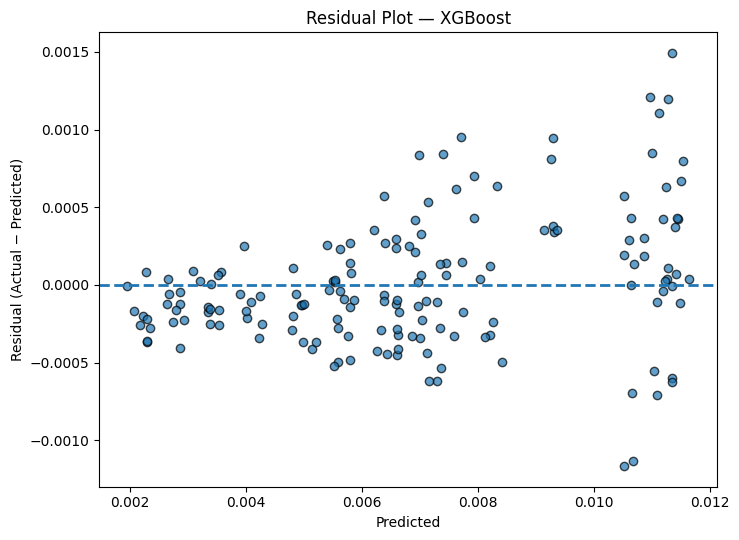

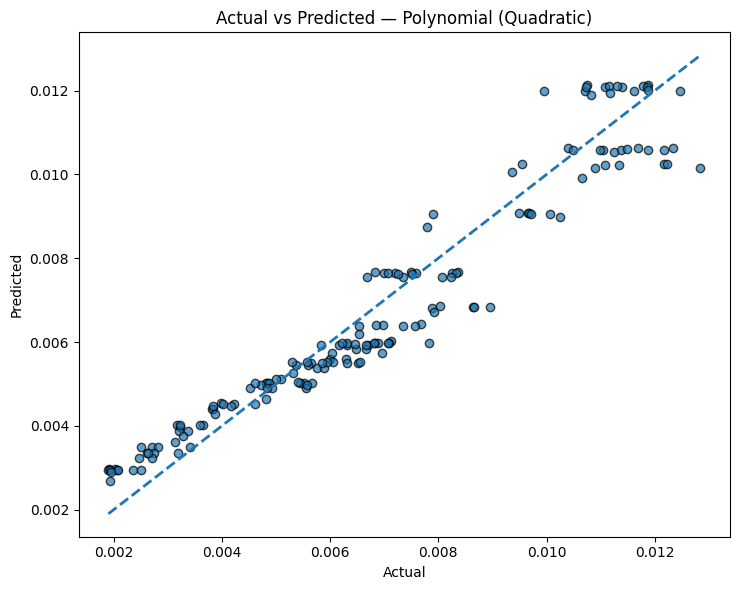

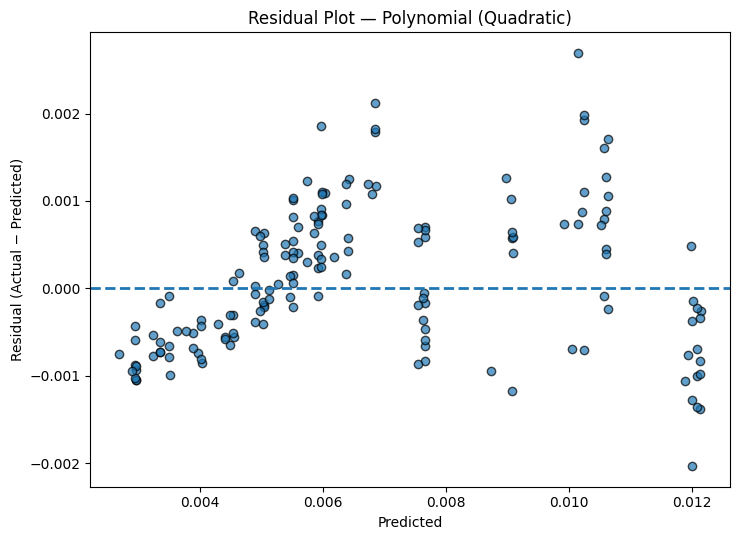

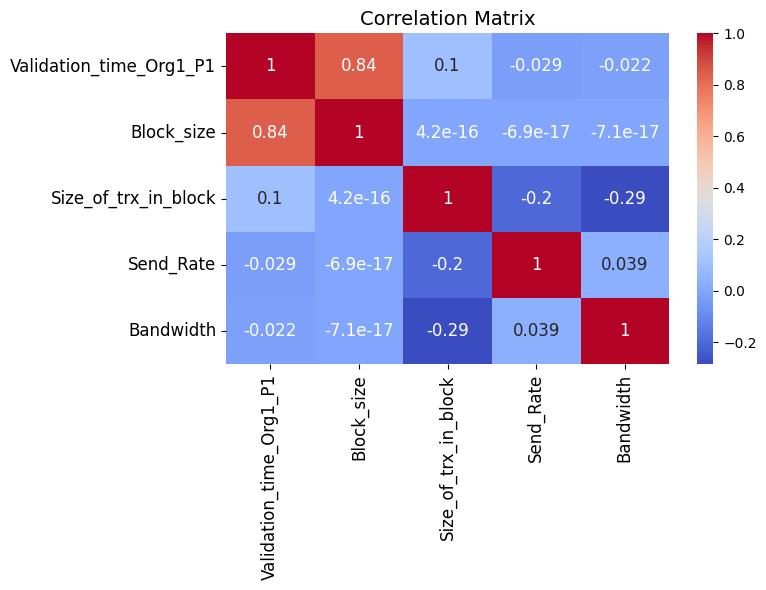

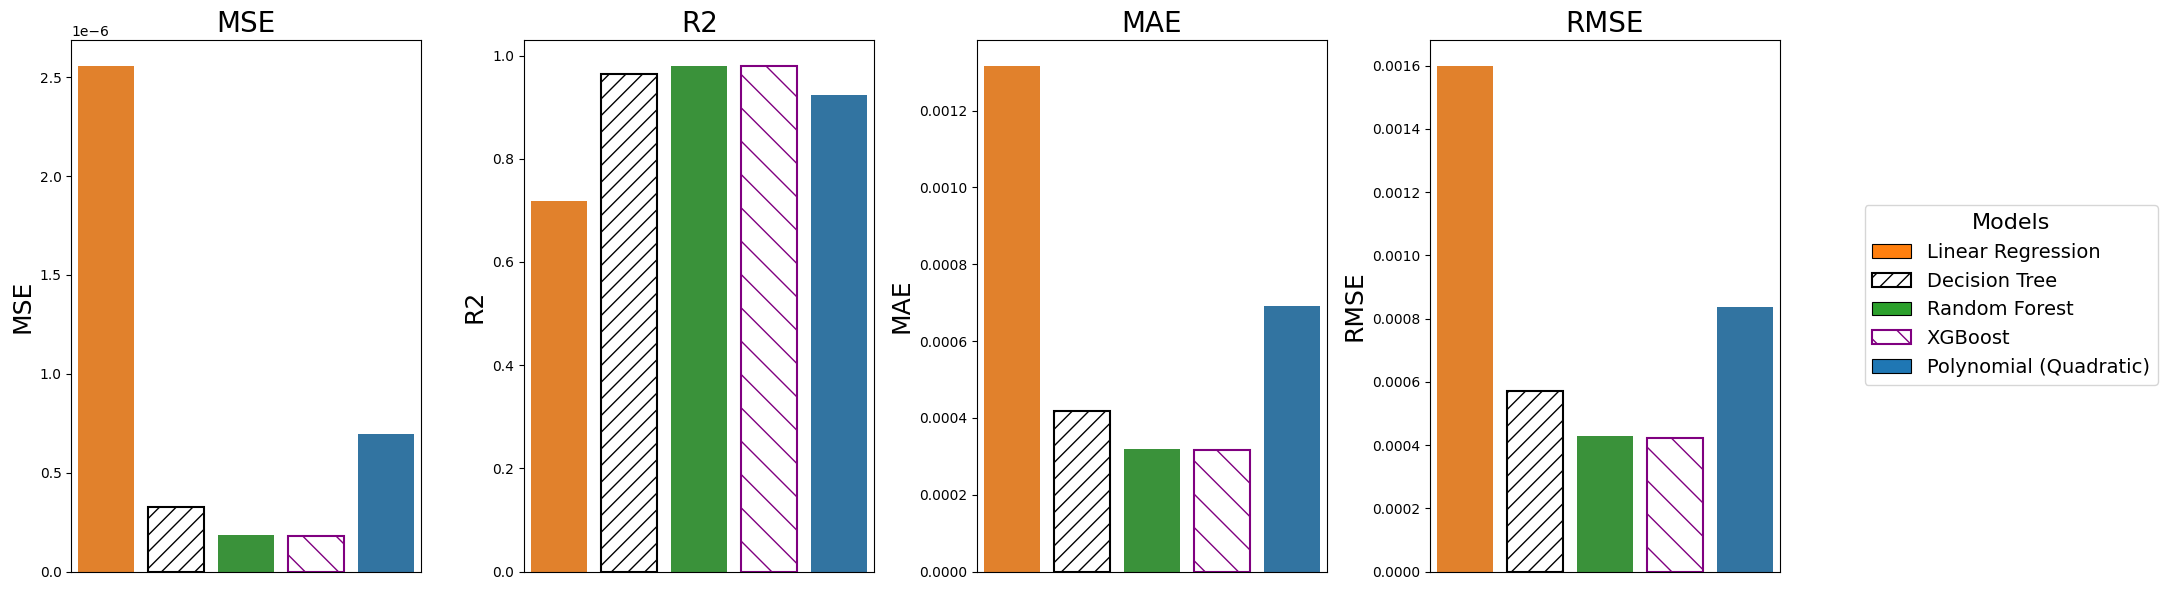

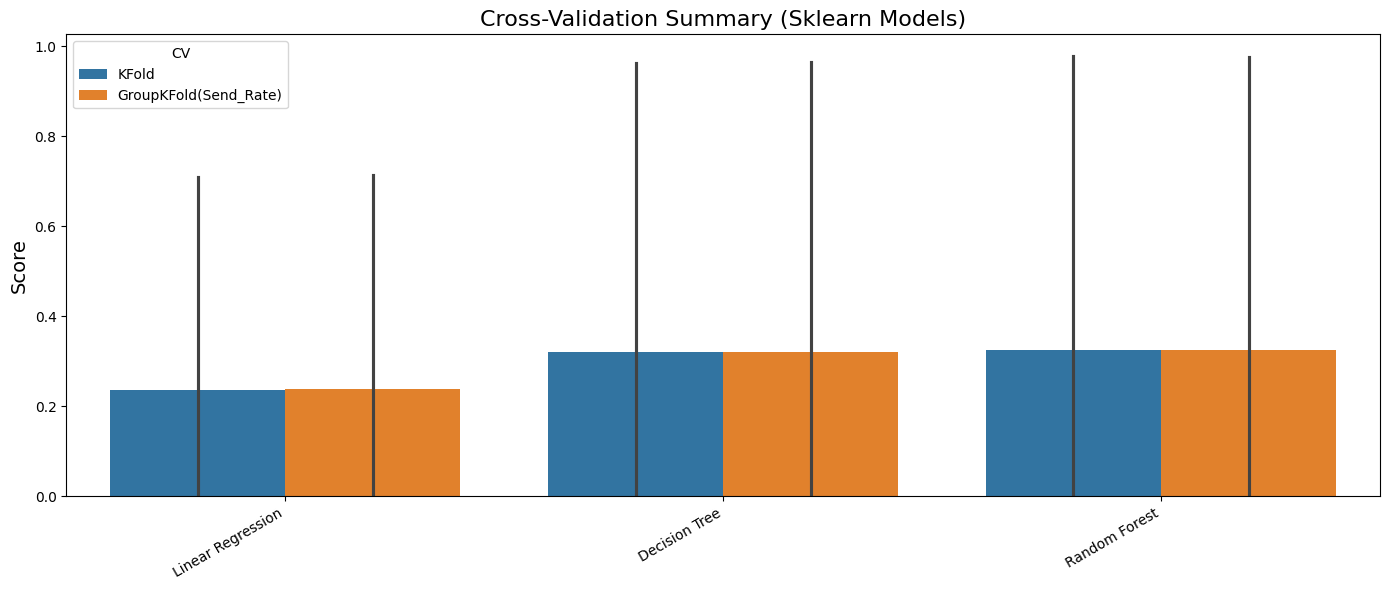


Saved models and quadratic artifacts successfully.


In [6]:
 #all model for peer0-Org1 validation time v2  


"""
Model comparison for Validation_time_Org1_P1 (Org1 Peer0)

Goals (publication-friendly):
1) Train multiple regression models on the same feature set.
2) Report test-set metrics (MAE, RMSE, MSE, R2, MAPE) + simple baselines.
3) Run cross-validation:
   - KFold (random) for overall stability
   - GroupKFold (group by Send_Rate) to test generalization to unseen workload rates
4) Provide clean, consistent, high-quality plots:
   - Actual vs Predicted
   - Residual plots (diagnostic)
   - Metric comparison bars (MSE/R2/MAPE and MAE/RMSE/R2)
   - CV summary plot (MAE/RMSE/R2 from KFold and GroupKFold)

Notes on scaling:
- Tree-based models (DecisionTree/RandomForest/XGBoost) do NOT require feature scaling.
- Linear regression benefits from scaling only when regularization is used; plain LinearRegression is fine.
- Quadratic curve_fit DOES benefit from scaling (we scale only inside that block, without leakage).

Assumptions:
- df is already loaded and contains:
  Block_size, Size_of_trx_in_block, Send_Rate, Bandwidth, Validation_time_Org1_P1
"""

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})

from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import StandardScaler

from scipy.optimize import curve_fit
import xgboost as xgb

import matplotlib.patches as mpatches


# -----------------------------
# Helper metrics + plotting
# -----------------------------
def mean_absolute_percentage_error_safe(y_true, y_pred):
    """MAPE (%) ignoring zero targets to avoid division by zero."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def metrics_dict(y_true, y_pred):
    """Return standard regression metrics in a consistent dict."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    return {"MAE": float(mae), "RMSE": rmse, "MSE": float(mse), "R2": float(r2), "MAPE(%)": float(mape)}

def plot_actual_vs_predicted(y_true, y_pred, model_name, save_pdf=False):
    plt.figure(figsize=(7.5, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], '--', linewidth=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'actual_vs_pred_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def plot_residuals(y_true, y_pred, model_name, save_pdf=False):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(7.5, 5.5))
    plt.scatter(y_pred, residuals, alpha=0.7, edgecolors='k')
    plt.axhline(0, linestyle='--', linewidth=2)
    plt.xlabel('Predicted')
    plt.ylabel('Residual (Actual − Predicted)')
    plt.title(f'Residual Plot — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'residuals_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def styled_metric_bars(plot_df, metric_names, title, filename_pdf, model_colors, hatch_rules):
    """
    Publication-friendly bar chart (one row per model, one panel per metric).
    Uses consistent colors and hatches for selected models.
    """
    melted = plot_df.melt(id_vars='Models', value_vars=metric_names, var_name='Metric', value_name='Score')

    plt.figure(figsize=(18, 6))
    for i, metric in enumerate(metric_names, 1):
        plt.subplot(1, len(metric_names), i)
        ax = sns.barplot(
            x='Models', y='Score',
            data=melted.query("Metric == @metric"),
            palette=[model_colors.get(m, '#FFFFFF') for m in plot_df['Models'].tolist()],
            hue='Models', dodge=False, legend=False
        )

        # Apply hatches/edges
        for bar, model in zip(ax.patches, plot_df['Models'].tolist()):
            hatch, face_none, edge_color, lw = hatch_rules.get(model, ("", False, None, 0.8))
            bar.set_hatch(hatch)

            if face_none:
                bar.set_facecolor('none')
            if edge_color is not None:
                bar.set_edgecolor(edge_color)
            bar.set_linewidth(lw)

        plt.title(metric, fontsize=20)
        plt.ylabel(metric, fontsize=18)
        plt.xlabel('')
        plt.xticks([], [])  # clean style like your old plot

    # Legend (custom, consistent with styles)
    legend_handles = []
    for m in plot_df['Models'].tolist():
        hatch, face_none, edge_color, lw = hatch_rules.get(m, ("", False, "black", 0.8))
        fc = 'none' if face_none else model_colors.get(m, '#FFFFFF')
        ec = edge_color if edge_color is not None else 'black'
        legend_handles.append(mpatches.Patch(facecolor=fc, edgecolor=ec, linewidth=lw, hatch=hatch, label=m))

    plt.gcf().legend(
        handles=legend_handles,
        loc='center',
        bbox_to_anchor=(1.12, 0.5),
        fontsize=14,
        title='Models',
        title_fontsize=16
    )

    plt.tight_layout()
    plt.savefig(filename_pdf, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()


# -----------------------------
# 0) Data / Features
# -----------------------------
# df must exist already
# df.head()

feature_cols = ['Block_size', 'Size_of_trx_in_block', 'Send_Rate', 'Bandwidth']
target_col = 'Validation_time_Org1_P1'

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# 1) Baselines (sanity checks)
# -----------------------------
baseline_mean = DummyRegressor(strategy="mean")
baseline_mean.fit(X_train, y_train)
pred_mean = baseline_mean.predict(X_test)
print("Baseline (mean):", metrics_dict(y_test, pred_mean))

baseline_block_only = LinearRegression()
baseline_block_only.fit(X_train[['Block_size']], y_train)
pred_block_only = baseline_block_only.predict(X_test[['Block_size']])
print("Baseline (Block_size only):", metrics_dict(y_test, pred_block_only))


# -----------------------------
# 2) Train models (same split)
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    # XGBoost: keep sklearn wrapper for train/test evaluation
    "XGBoost": xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9
    ),
}

test_results = {}
y_preds = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    y_preds[name] = pred
    test_results[name] = metrics_dict(y_test, pred)

print("\n=== Test-set results (single split) ===")
for name in models.keys():
    r = test_results[name]
    print(f"\n{name}:")
    print(f"  MAE:     {r['MAE']:.10f}")
    print(f"  RMSE:    {r['RMSE']:.10f}")
    print(f"  MSE:     {r['MSE']:.10e}")
    print(f"  R2:      {r['R2']:.6f}")
    print(f"  MAPE(%): {r['MAPE(%)']:.4f}")


# -----------------------------
# 3) Quadratic regression (2 features) without leakage (curve_fit)
# -----------------------------
# This is a parametric baseline you can interpret and print as an equation.
quad_features = ['Block_size', 'Send_Rate']

def quadratic_model(X_arr, a, b, c, d, e, f):
    x1, x2 = X_arr
    return a * x1**2 + b * x1 * x2 + c * x2**2 + d * x1 + e * x2 + f

scaler_quad = StandardScaler()
X_train_q = scaler_quad.fit_transform(X_train[quad_features])
X_test_q = scaler_quad.transform(X_test[quad_features])

params, covariance = curve_fit(quadratic_model, X_train_q.T, y_train.values)
a, b, c, d, e, f = params

pred_quad = quadratic_model(X_test_q.T, *params)
test_results["Polynomial (Quadratic)"] = metrics_dict(y_test, pred_quad)
y_preds["Polynomial (Quadratic)"] = pred_quad

equation_scaled = (
    f"Validation_time = ({a:.6g} * x1^2) + ({b:.6g} * x1*x2) + ({c:.6g} * x2^2) "
    f"+ ({d:.6g} * x1) + ({e:.6g} * x2) + ({f:.6g}), "
    f"where x1,x2 are StandardScaler-transformed Block_size, Send_Rate."
)

print("\nPolynomial (Quadratic) equation (on standardized features):")
print(equation_scaled)


# -----------------------------
# 4) Cross-validation (publishable stability)
# -----------------------------
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# GroupKFold: generalize to unseen Send_Rate conditions
groups = df["Send_Rate"].astype(str)
cv_group = GroupKFold(n_splits=min(3, df["Send_Rate"].nunique()))

cv_summary = []

# IMPORTANT: sklearn cross_validate may fail with XGBoost+new sklearn in some environments.
# To keep this script robust + publishable: we do sklearn CV for sklearn models,
# and XGBoost CV using xgb.cv (official).
for name, mdl in models.items():
    if name == "XGBoost":
        continue

    out_k = cross_validate(mdl, X, y, cv=cv_kfold, scoring=scoring, return_train_score=False)
    out_g = cross_validate(mdl, X, y, cv=cv_group, groups=groups, scoring=scoring, return_train_score=False)

    cv_summary.append({
        "Models": name,
        "CV": "KFold",
        "MAE": float(-out_k["test_MAE"].mean()),
        "RMSE": float(-out_k["test_RMSE"].mean()),
        "R2": float(out_k["test_R2"].mean()),
    })
    cv_summary.append({
        "Models": name,
        "CV": "GroupKFold(Send_Rate)",
        "MAE": float(-out_g["test_MAE"].mean()),
        "RMSE": float(-out_g["test_RMSE"].mean()),
        "R2": float(out_g["test_R2"].mean()),
    })

# XGBoost CV (robust, official)
dtrain = xgb.DMatrix(X.values, label=y.values)
params_xgb = {
    "objective": "reg:squarederror",
    "seed": 42,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
}
cv_xgb = xgb.cv(
    params=params_xgb,
    dtrain=dtrain,
    num_boost_round=800,
    nfold=5,
    metrics=("rmse",),
    early_stopping_rounds=30,
    seed=42,
    verbose_eval=False
)
xgb_rmse = float(cv_xgb["test-rmse-mean"].iloc[-1])

print("\nXGBoost 5-fold CV (xgb.cv):")
print("  RMSE mean (last):", xgb_rmse)
print("  RMSE std  (last):", float(cv_xgb["test-rmse-std"].iloc[-1]))


cv_df = pd.DataFrame(cv_summary)
print("\n=== CV summary (sklearn models) ===")
print(cv_df)


# -----------------------------
# 5) Permutation importance (more reliable than tree impurity importance)
# -----------------------------
# Choose a best model for importance 
# Pick best model by lowest RMSE on the test set
best_model_name = min(test_results.keys(), key=lambda m: test_results[m]["RMSE"])

# Only sklearn models are in `models` (Quadratic isn't), so handle that case
if best_model_name in models:
    best_model = models[best_model_name]
else:
    best_model = None  # Quadratic

print("\nBest model (by Test RMSE):", best_model_name, test_results[best_model_name])

perm = permutation_importance(
    best_model,
    X_test, y_test,
    n_repeats=25,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_imp = pd.DataFrame({
    "Feature": X_test.columns,
    "ImportanceMean(MAE drop)": perm.importances_mean,
    "ImportanceStd": perm.importances_std
}).sort_values("ImportanceMean(MAE drop)", ascending=False)

print("\nPermutation importance (MAE drop):")
print(perm_imp)

# Plot permutation importances
plt.figure(figsize=(8, 5.5))
plt.barh(perm_imp["Feature"], perm_imp["ImportanceMean(MAE drop)"])
plt.xlabel("Importance (Mean MAE drop)")
plt.title(f"Permutation Importance — {best_model_name}")
plt.tight_layout()
plt.savefig("permutation_importance.pdf", dpi=600)
plt.show()


# -----------------------------
# 6) Publication plots
# -----------------------------
# 6.1 Actual vs predicted + residuals (pick top models)
for nm in ["Random Forest", "XGBoost", "Polynomial (Quadratic)"]:
    plot_actual_vs_predicted(y_test, y_preds[nm], nm, save_pdf=True)
    plot_residuals(y_test, y_preds[nm], nm, save_pdf=True)

# 6.2 Keep your correlation plot (optional)
corr_cols = [target_col] + feature_cols
correlation_matrix = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('validation_correlation_matrix.pdf', format='pdf', dpi=600)
plt.show()

# 6.3 Metric comparison plots (bars) in your style (colors + hatches)
# Build a single test-results table for plotting
plot_models_order = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Polynomial (Quadratic)"
]
plot_table = pd.DataFrame([
    {"Models": m,
     "MSE": test_results[m]["MSE"],
     "R2": test_results[m]["R2"],
     "MAPE": test_results[m]["MAPE(%)"],
     "MAE": test_results[m]["MAE"],
     "RMSE": test_results[m]["RMSE"]}
    for m in plot_models_order
])

# Colors (keep your original palette idea)
model_colors = {
    "Linear Regression": "#ff7f0e",
    "Decision Tree": "none",
    "Random Forest": "#2ca02c",
    "XGBoost": "none",
    "Polynomial (Quadratic)": "#1f77b4",
}

# Hatch rules: (hatch, face_none, edge_color, linewidth)
hatch_rules = {
    "Decision Tree": ("//", True, "black", 1.5),
    "XGBoost": ("\\", True, "#800080", 1.5),
    # others default
}

# Plot A: your original trio (MSE, R2, MAPE)
styled_metric_bars(
    plot_df=plot_table[["Models", "MSE", "R2", "MAE", "RMSE"]],
    metric_names=["MSE", "R2", "MAE", "RMSE",],
    title="Model Comparison (Test Set)",
    filename_pdf="validation_models_mse_r2_mape.pdf",
    model_colors=model_colors,
    hatch_rules=hatch_rules
)

# 6.4 CV summary plot (KFold vs GroupKFold)
if not cv_df.empty:
    # Pivot into long format for plotting
    cv_plot = cv_df.melt(id_vars=["Models", "CV"], value_vars=["MAE", "RMSE", "R2"],
                         var_name="Metric", value_name="Score")

    plt.figure(figsize=(14, 6))
    ax = sns.barplot(data=cv_plot, x="Models", y="Score", hue="CV")
    plt.title("Cross-Validation Summary (Sklearn Models)", fontsize=16)
    plt.ylabel("Score", fontsize=14)
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("cv_summary.pdf", dpi=600)
    plt.show()


# -----------------------------
# 7) Save fitted models/objects (for reuse)
# -----------------------------
import joblib

joblib.dump(models["Linear Regression"], "VP1Org1_linear_model.pkl")
joblib.dump(models["Decision Tree"], "VP1Org1_tree_model.pkl")
joblib.dump(models["Random Forest"], "VP1Org1_forest_model.pkl")
joblib.dump(models["XGBoost"], "VP1Org1_xgboost_model.pkl")

# Quadratic params + scaler for later prediction
joblib.dump(params, "VP1Org1_quadratic_params.pkl")
joblib.dump(scaler_quad, "VP1Org1_quadratic_scaler.pkl")

print("\nSaved models and quadratic artifacts successfully.")

